In [1]:
import os
import tarfile
import urllib.request

from country_name import country_name_rus

CL =[ "Afganistan","China","CAR", "Ethiopia",
      "India", "Iran","KNDR", "Libya", "Morocco", "Sudan",
      "Syria", "Turkey", "Argentina", "DRK_Congo", "Burkina_Faso",
      "Niger", "Mali", "Senegal", "Egipet", "Gvineya", "Venesuela",
      "Algeria", "Zimbabve", "Tunis", "Boliviya", "Braziliya",
      "Yuar", "Burundi", "Ruanda", "Mongoliya", 'Pakistan', 
     "Chili", 'Bangladesh', 'Benin', 'Gabon', 'Laos', 'Chad' , 
     'Keniya', 'Indoneziya','Iordaniya', 'Irak', 'Kambodzha', 'Kuba',
     'Tailand','Urugvay', 'Kamerun', 'Madagaskar', 'Mozambik', 'Yaponiya',
     'Mexico', 'Oae','Saudovskaya_araviya', 'Yemen', 'Pakistan', 'Laos', 'RK_Congo',
     'angola', 'belorussiya', 'litva', 'franciya', 'botsvana', 'vengriya',
     'italiya', 'germaniya' , 'palestina', 'izrail', 'tayvan', 'tanzaniya',
     'ispaniya',  'livan', 'oman','paragvay', 'peru', 'portugaliya', 'ssha','kolumbiya', 'uganda', 'nigeriya',
     'gana', 'Respublika-koreya', 'ekvatorialnaya-gvineya', 'kot-d-ivuar',  'namibiya', 'zambiya','vetnam',  'myanma'
    ]

DIR_PATH= {}
DOWNLOAD_ROOT = "D:/ML/"
print(DOWNLOAD_ROOT)
#DATASET_PATH = os.path.join("datasets", "Countries")
DATASET_PATH = os.path.join("datasets", "Countries_V3")

for item in CL:
    DIR_PATH[country_name_rus[item]] = os.path.join(DATASET_PATH, item)
    
filenames = {}
for items in DIR_PATH.keys():   
    filenames[items] = [name for name in sorted(os.listdir(DIR_PATH[items])) ] 
    print(items)

D:/ML/
Афганистан
КНР
Центрально-Африканская Республика
Эфиопия 
Индия
Иран
КНДР
Ливия
Морокко
Судан
Сирия
Турция
Аргентина
ДРК (Конго)
Буркина-Фасо
Нигер
Мали
Сенегал
Египет
Гвинея
Венесуэла
Алжир
Зимбабве
Тунис
Боливия
Бразилия
ЮАР
Бурунди
Руанда
Монголия
Пакистан
Чили
Бангладеш
Бенин
Габон
Лаос
Чад
Кения
Индонезия
Иордания
Ирак
Камбоджа
Куба
Таиланд
Уругвай
Камерун
Мадагаскар
Мозамбик
Япония
Мексика
ОАЭ
Саудовская Аравия
Йемен
Республика Конго
Ангола
Беларусь
Литва
Франция
Ботсвана
Венгрия
Италия
Германия
Палестина
Израиль
КНР (Тайвань)
Танзания
Испания
Ливан
Оман
Парагвай
Перу
Португалия
США
Колумбия
Уганда
Нигерия
Гана
Южная Корея
Экваториальная Гвинея
Кот-д'Ивуар
Намибия
Замбия
Вьетнам
Мьянма


In [2]:
len(country_name_rus.keys())

84

In [3]:
stemming=True # Stemming control
if stemming:
    from nltk.stem.snowball import SnowballStemmer
    stemmer = SnowballStemmer("russian")

In [4]:
from stop_words_ru import ru_stopwords

In [5]:
load_from_DB = True # True - Загрузка БД из json файла
                        # False - Пересборка  json файла из отдельных текстовых файлов

In [6]:
from charset_normalizer import from_path
import string

def remove_chars_from_text(text, chars):
    # return "".join([ch for ch in text if ch not in chars])
    content = ''
    for ch in text:
        if ch not in chars:
            content = content + ''.join(ch)
        else:
            content = content + ''.join(' ')
    return content

import re

def remove_emojis(data):
    emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642" 
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
                      "]+", re.UNICODE)
    return re.sub(emoj, ' ', data)
spec_chars = string.punctuation + '\r' + '\n\xa0«»\t—…' 

def clean_text (post_text):    
    text_post = re.sub(r'https?:\/\/.*[\r\n]*', ' ', post_text, flags=re.MULTILINE)
    text_post = re.sub(r'#[^\s|\n]+', ' ', text_post)
    text_post = remove_emojis(text_post)
    text_post = text_post.replace('Тут была французская Западная Африка | Подписаться', ' ')
    text_post = text_post.replace('Африканская инициатива | Подписаться', ' ')
    text_post = text_post.replace('@sex_drugs_kahlo — латиноамериканское счастье [нет]', ' ')
    text_post = text_post.replace('Подписаться | Обратная связь', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('/Синьхуа/', ' ')
    text_post = text_post.replace('[Full Text]', ' ')
    return text_post

import time
import random
import codecs, json
from datetime import datetime

def json_cleaning_stemm (json_file_name):
    with open(json_file_name, encoding='utf-8') as json_file:
        article_data = json.load(json_file)
    result_data = {}   
    for item in article_data.keys():
        x_temp = []
        content = str(article_data[item]['text']).lower()
        content = remove_emojis(content)
        content = remove_chars_from_text(content, spec_chars)
        content = remove_chars_from_text(content, string.digits)
        for i in range(1, 10):
            content = content.replace('  ', ' ')
        filtered_words = []
        for token in content.split():
            if token not in ru_stopwords and len(token) > 2:
                if stemming and token is not None:
                    filtered_words.append(stemmer.stem(token))
                    # print('{} -{}'.format(token,stemmer.stem(token)))
                else:
                    filtered_words.append(token)
    
        content = ' '.join(filtered_words)   
        result_data [item] = {'text': content, 'country': article_data[item]['country']}
    try: 
        with codecs.open('{}_cleaning_stemm.json'.format(json_file_name[:-5]), 'w', encoding='utf-8') as f:
             f.write(json.dumps(result_data, sort_keys = True, ensure_ascii=False))    
    except Exception as ex:
        print(ex)
    return


In [7]:
import pandas as pd 
    #Reading the JSON File 
x_temp = []
y_temp = []

if load_from_DB:
    json_cleaning_stemm ('Country_DB_V4_25-01-2025.json')     
    df = pd.read_json('Country_DB_V4_25-01-2025_cleaning_stemm.json').T
else:
    for item in filenames.keys():
        post_temp=[]
        for names in filenames[item]:
            content = str(from_path(DIR_PATH[item]+"\\"+names).best())            
            content = clean_text(content)                
            x_temp.append(content)
            y_temp.append(item)
    try:
        article_data ={}
        for article_id in range(0, len(x_temp)):
            #print (article_id)
            article_data [article_id] = {'text': x_temp [article_id], 'country': y_temp [article_id]}
        time = datetime.now().strftime("%d-%m-%Y")
        with codecs.open('Country_DB_V4_{}.json'.format(time), 'w', encoding='utf-8') as f:
             f.write(json.dumps(article_data, sort_keys = True, ensure_ascii=False))
        json_cleaning_stemm ('Country_DB_V4_{}.json'.format(time))     
        df = pd.read_json('Country_DB_V4_{}_cleaning_stemm.json'.format(time)).T
    except Exception as ex:
        print(ex)

json_cleaning_stemm ('Country_DB_V4_checked_25-01-2025.json')
df_checked = pd.read_json('Country_DB_V4_checked_25-01-2025_cleaning_stemm.json').T
MergeJson = pd.concat([df, df_checked], axis=0)
        



In [8]:
df_checked

,country,text
0,Судан,судан сезон наводнен пострада тысяч человек су...
1,Судан,срыв америка суданск переговор каир переходн с...
10,Турция,глав суверен совет суда встрет президент турц ...
100,Ирак,президент ира масуд пезешкиа правительствен де...
1000,КНР,кита успешн запуст нов групп спутник дистанцио...
...,...,...
995,Иран,ира призва переосмысл поведен отношен западн а...
996,Иран,возобновлен работ иранск посольств сир сто пов...
997,Южная Корея,отстранен власт президент гроз нов вызов допро...
998,КНР,цзиньпин призва провинц хайнан вписа собствен ...


In [9]:
df

,country,text
0,Афганистан,источник мест пишут вертолет таджикиста отстре...
1,Афганистан,присутств запад афганистан минимальн поддержк ...
10,Афганистан,руководств афганск талиба запрещен террористич...
100,Афганистан,росс направ афганиста спецборт гуманитарн помо...
1000,КНР,офис казахск китайск компан cnpc актобемунайга...
...,...,...
9995,Руанда,сми руанд обвин конг причастн похищен двух руа...
9996,Руанда,африканск союз выраз беспокойств кризис отноше...
9997,Руанда,церков англ раскритикова план правительств отп...
9998,Руанда,трасс подтверд британ начнет отправля нелегаль...


In [10]:
len(set(MergeJson["country"].tolist()))

84

In [11]:
for country in set(MergeJson["country"].tolist()): 
    sum = MergeJson[MergeJson["country"]==country]['text'].count()
    print(f'{country} - {sum} ')

Танзания - 217 
Мьянма - 199 
Ливан - 203 
ДРК (Конго) - 469 
Монголия - 88 
Бенин - 193 
Чад - 246 
Вьетнам - 326 
Йемен - 209 
Египет - 263 
Намибия - 172 
Алжир - 189 
Кения - 207 
Кот-д'Ивуар - 223 
Сенегал - 152 
Иран - 642 
Таиланд - 74 
Мексика - 1080 
Бразилия - 243 
Ирак - 69 
Португалия - 204 
Тунис - 125 
Мозамбик - 236 
Турция - 1133 
Перу - 210 
Мали - 301 
Гана - 231 
Индонезия - 182 
ОАЭ - 385 
Колумбия - 196 
Афганистан - 463 
Ангола - 232 
Палестина - 220 
Литва - 210 
Уганда - 218 
Замбия - 200 
Нигер - 89 
Иордания - 211 
Франция - 210 
Беларусь - 220 
Камерун - 224 
Италия - 207 
Сирия - 141 
Боливия - 118 
Уругвай - 44 
Эфиопия  - 346 
Габон - 89 
Испания - 201 
Камбоджа - 70 
Куба - 229 
Ботсвана - 102 
Израиль - 215 
Гвинея - 106 
Буркина-Фасо - 213 
Нигерия - 250 
ЮАР - 70 
Венгрия - 207 
Бурунди - 73 
Республика Конго - 206 
Центрально-Африканская Республика - 545 
Оман - 214 
КНР - 2422 
Саудовская Аравия - 214 
Судан - 391 
Лаос - 206 
Чили - 83 
Япония - 270

In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
if load_from_DB:
    X = np.array(MergeJson['text'], dtype=object)
    y = np.array(MergeJson['country'])
else:
    X = np.array(x_temp, dtype=object)
    y = np.array(y_temp)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
len(X)

23703

In [14]:
len(y)

23703

In [15]:
MergeJson

,country,text
0,Афганистан,источник мест пишут вертолет таджикиста отстре...
1,Афганистан,присутств запад афганистан минимальн поддержк ...
10,Афганистан,руководств афганск талиба запрещен террористич...
100,Афганистан,росс направ афганиста спецборт гуманитарн помо...
1000,КНР,офис казахск китайск компан cnpc актобемунайга...
...,...,...
995,Иран,ира призва переосмысл поведен отношен западн а...
996,Иран,возобновлен работ иранск посольств сир сто пов...
997,Южная Корея,отстранен власт президент гроз нов вызов допро...
998,КНР,цзиньпин призва провинц хайнан вписа собствен ...


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,5), min_df=6)
print (tfidf)
#tfidf= CountVectorizer(max_features=20000)
X_train_transformed = tfidf.fit_transform(X_train)
#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf = DecisionTreeClassifier()
rf.fit(X_train_transformed, y_train)

y_pred = rf.predict_proba(X_train_transformed)[:, 1]
score = cross_val_score(rf, X_train_transformed, y_train, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf, X_train_transformed, y_train, scoring='accuracy'))
print(cross_val_score(rf, X_train_transformed, y_train, scoring='f1_macro'))    

TfidfVectorizer(max_features=20000, min_df=6, ngram_range=(1, 5))
[CV] END ................................ score: (test=0.788) total time=  13.6s
[CV] END ................................ score: (test=0.786) total time=  13.6s
[CV] END ................................ score: (test=0.790) total time=  13.6s
0.7880907862299283
[0.78125942 0.78999699 0.78993369 0.77787824 0.78149488]
[0.74359759 0.74930729 0.75356328 0.74113531 0.74788748]


In [17]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed = tfidf.transform(X_test)

rf.fit(X_test_transformed, y_test)

y_pred = rf.predict(X_test_transformed)

print("Precision: {:.2f}%".format(100 * precision_score(y_test, y_pred, average='weighted')))
print("Recall: {:.2f}%".format(100 * recall_score(y_test, y_pred, average='weighted')))

Precision: 98.58%
Recall: 98.44%


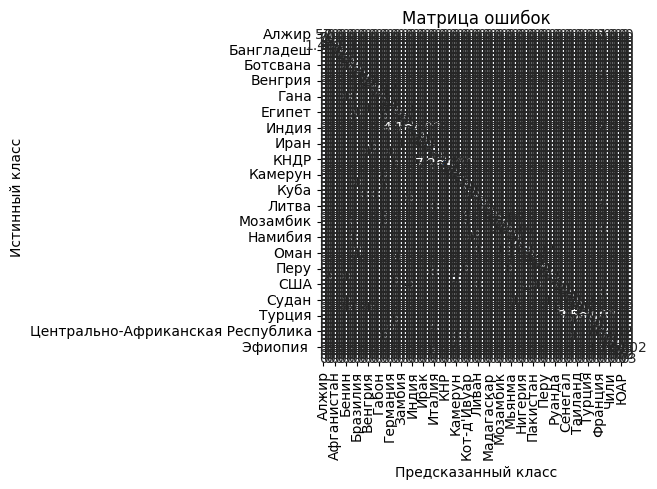

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns #pip install seaborn
from sklearn.metrics import confusion_matrix
import pandas as pd
# Создать матрицу ошибок
matrix = confusion_matrix(y_test, y_pred)
# Создать структуру DataFrame библиотеки pandas
dataframe = pd.DataFrame(matrix, index=rf.classes_, columns=rf.classes_)
# Создать тепловую карту
sns.heatmap(dataframe, annot=True, cbar=None, cmap="Blues")
plt.title("Maтpицa ошибок")
plt.tight_layout()
plt.ylabel("Истинный класс")
plt.xlabel("Предсказанный класс")
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,5), min_df=6)
X_train_transformed = tfidf.fit_transform(X_train)

#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf_RandomForest = RandomForestClassifier(random_state=3, n_jobs=-1, class_weight="balanced", oob_score=True)
rf_RandomForest.fit(X_train_transformed, y_train)

y_pred = rf_RandomForest.predict_proba(X_train_transformed)[:, 1]
score = cross_val_score(rf_RandomForest, X_train_transformed, y_train, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf_RandomForest, X_train_transformed, y_train, scoring='accuracy'))
print(cross_val_score(rf_RandomForest, X_train_transformed, y_train, scoring='f1_macro')) 
print(rf_RandomForest.oob_score_)

[CV] END ................................ score: (test=0.860) total time=   6.8s
[CV] END ................................ score: (test=0.855) total time=   6.9s
[CV] END ................................ score: (test=0.854) total time=   6.6s
0.8562558842815807
[0.86050015 0.86833384 0.85533454 0.85111513 0.86256781]
[0.83571683 0.83699603 0.82620717 0.82619563 0.83835204]
0.8541465766634523


In [31]:
from sklearn.model_selection import RandomizedSearchCV
n_estimators = [int(x) for x in np.linspace(start = 250, stop = 500, num = 10)]
max_features = ['log2', 'sqrt']
max_depth = [int(x) for x in np.linspace(start = 100, stop = 250, num = 10)]
min_samples_split = [int(x) for x in np.linspace(start = 2, stop = 50, num = 5)]
min_samples_leaf = [int(x) for x in np.linspace(start = 2, stop = 50, num = 5)]
bootstrap = [True, False]
param_dist = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth               
               }
rs = RandomizedSearchCV(rf_RandomForest, 
                        param_dist, 
                        n_iter = 10, 
                        cv = 3, 
                        verbose = 1, 
                        n_jobs=-1, 
                        random_state=3,
                       )
rs.fit(X_train_transformed, y_train)
rs.best_params_
#{'n_estimators': 325,
# 'max_features': 'sqrt',
# 'max_depth': 166,
# 'bootstrap': True}

Fitting 3 folds for each of 10 candidates, totalling 30 fits


{'n_estimators': 500, 'max_features': 'sqrt', 'max_depth': 200}

In [32]:
rs_df = pd.DataFrame(rs.cv_results_).sort_values('rank_test_score').reset_index(drop=True)
rs_df = rs_df.drop([
            'mean_fit_time', 
            'std_fit_time', 
            'mean_score_time',
            'std_score_time', 
            'params', 
            'split0_test_score', 
            'split1_test_score', 
            'split2_test_score', 
            'std_test_score'],
            axis=1)
rs_df.head(10)

,param_n_estimators,param_max_features,param_max_depth,mean_test_score,rank_test_score
0,500,sqrt,200,0.861017,1
1,444,sqrt,250,0.860776,2
2,250,sqrt,233,0.859752,3
3,277,sqrt,133,0.857220,4
4,250,sqrt,150,0.857160,5
5,416,log2,133,0.844744,6
6,305,log2,166,0.844262,7
7,333,log2,250,0.842394,8
8,250,log2,183,0.841731,9
9,250,log2,133,0.840766,10


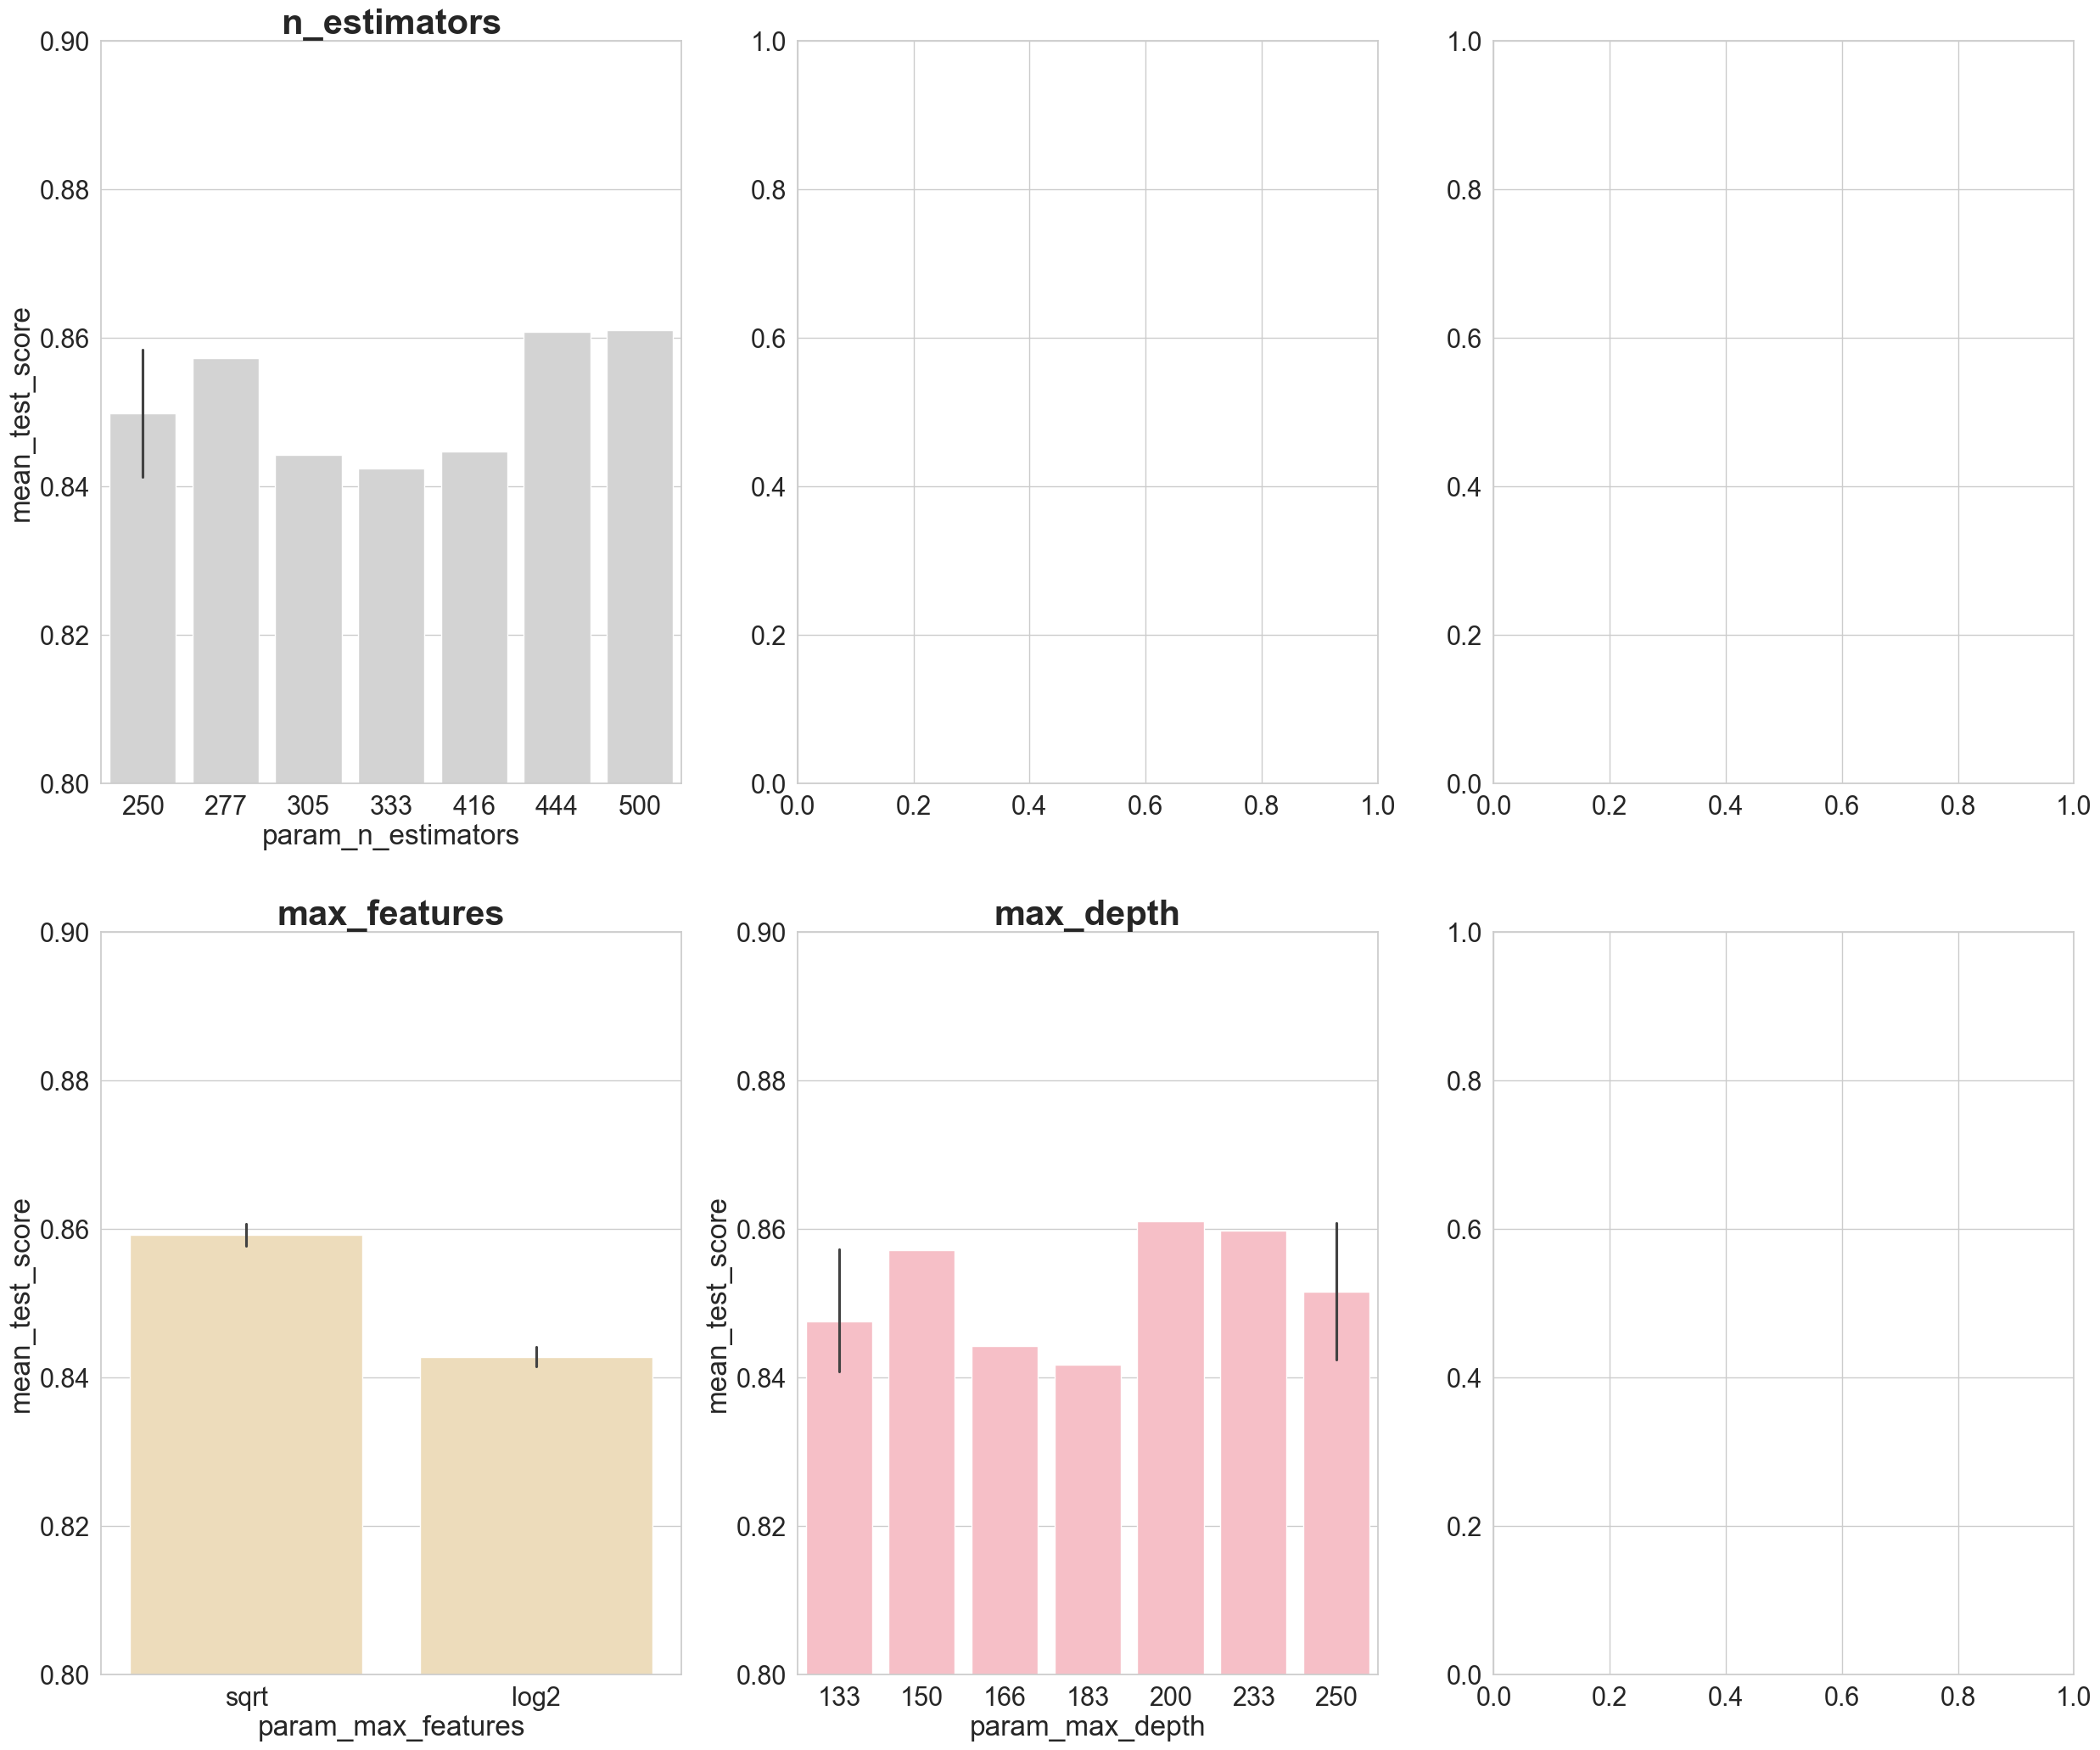

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axs = plt.subplots(ncols=3, nrows=2)
sns.set(style="whitegrid", color_codes=True, font_scale = 2)
fig.set_size_inches(30,25)
sns.barplot(x='param_n_estimators', y='mean_test_score', data=rs_df, ax=axs[0,0], color='lightgrey')
axs[0,0].set_ylim([.8,.9]) 
axs[0,0].set_title(label = 'n_estimators', size=30, weight='bold')
sns.barplot(x='param_max_features', y='mean_test_score', data=rs_df, ax=axs[1,0], color='wheat')
axs[1,0].set_ylim([.8,.9]) 
axs[1,0].set_title(label = 'max_features', size=30, weight='bold')
sns.barplot(x='param_max_depth', y='mean_test_score', data=rs_df, ax=axs[1,1], color='lightpink')
axs[1,1].set_ylim([.8,.9]) 
axs[1,1].set_title(label = 'max_depth', size=30, weight='bold')
plt.show()

In [20]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed = tfidf.transform(X_test)

rf_RandomForest.fit(X_test_transformed, y_test)

y_pred_RandomForest = rf_RandomForest.predict(X_test_transformed)

print("Precision: {:.2f}%".format(100 * precision_score(y_test, y_pred_RandomForest, average='weighted')))
print("Recall: {:.2f}%".format(100 * recall_score(y_test, y_pred_RandomForest, average='weighted')))

Precision: 98.52%
Recall: 98.41%


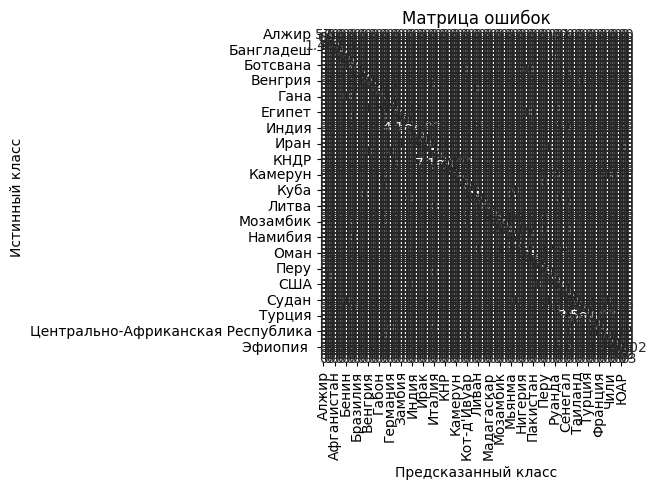

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns #pip install seaborn
from sklearn.metrics import confusion_matrix
import pandas as pd
# Создать матрицу ошибок
matrix = confusion_matrix(y_test, y_pred_RandomForest)
# Создать структуру DataFrame библиотеки pandas
dataframe = pd.DataFrame(matrix, index=rf_RandomForest.classes_, columns=rf_RandomForest.classes_)
# Создать тепловую карту
sns.heatmap(dataframe, annot=True, cbar=None, cmap="Blues")
plt.title("Maтpицa ошибок")
plt.tight_layout()
plt.ylabel("Истинный класс")
plt.xlabel("Предсказанный класс")
plt.show()

In [22]:
impoгtances = rf_RandomForest.feature_importances_
feature_imp_df = pd.DataFrame({'Word': tfidf.get_feature_names_out(), 'Importance': impoгtances}).sort_values('Importance', ascending=False) 
print(feature_imp_df[:50])

             Word  Importance
7837   мадагаскар    0.006731
18047       уганд    0.006269
7727         литв    0.006191
1664       бурунд    0.005840
17874       тунис    0.005388
9020        намиб    0.005345
17436      танзан    0.005227
12192    португал    0.005204
6049          инд    0.005149
17367     таиланд    0.005003
5705      зимбабв    0.004911
6529      камерун    0.004883
19985        япон    0.004864
11199         пер    0.004855
3218          ган    0.004798
632         алжир    0.004797
17908        турц    0.004797
5290         замб    0.004714
1313        бенин    0.004537
9598        нигер    0.004534
7932       марокк    0.004518
8701     мозамбик    0.004508
19054         цар    0.004445
19826       эфиоп    0.004437
6669          кен    0.004407
14968       руанд    0.004329
7864          мал    0.004304
8876        мьянм    0.004298
739         ангол    0.004243
1880        венгр    0.004135
859      аргентин    0.004015
6328        испан    0.003955
3238      

In [23]:
with open('./datasets/feature_importances_.txt', "w", encoding="utf-8") as some_file:
    some_file.write(feature_imp_df.to_string())

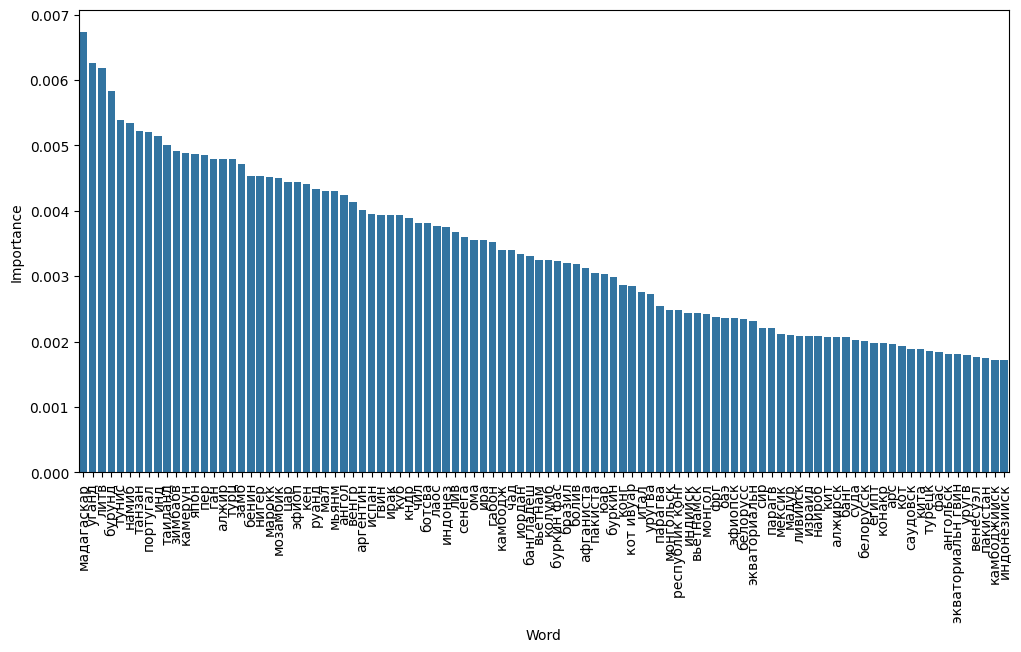

In [24]:
import pandas as pd
import seaborn as sns
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Word", y="Importance", data=feature_imp_df[:100])

ax.tick_params(axis='x', labelrotation=90)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# ax.set_xticks(ticks=ax.get_xticks(), labels=ax.get_xticklabels(), rotation=45, ha='right')
plt.show()


In [25]:
new_text = ['Нигер последовал примеру Мали, разорвав связи с Украиной после того, как пресс-секретарь разведывательного агентства Министерства обороны Украины признал, что Украина оказывала поддержку повстанцам, которые убили малийских вооруженных сил и российских агентов 25-27 июля в Тинзауатене, на севере Мали, недалеко от границы с Алжиром.Посол Украины в Сенегале также выразил безоговорочную поддержку малийским повстанцам, что привело к вызову посла в МИД Сенегала.',
            'Еще новости афганской промышленности. В Кандагаре спустя 18 лет возобновила работу текстильная фабрика. Официальные лица говорят, что они отремонтировали оборудование на фабрике за шесть месяцев, сообщают афганское СМИ. По словам работников фабрики, с возобновлением работы фабрики созданы рабочие места. 69-летний Мохаммад, проработавший на текстильной фабрике в Кандагаре значительное время, рад вернуться на работу.',
           'Накопленное непонимание между Китаем и США не может быть решено лишь одним подобным изящным жестом. Страны расходятся по широкому кругу вопросов, санкционный механизм против Китая не ослаблен. Поэтому отправка панд – это скорее демонстрация миролюбивой позиции Китая в противовес США.',
            'В Алжире, как правило, на похоронах мужчины сидят около дома, хорошо, если есть сад или терраса, а женщины в доме, надеть платок женщина должна обязательно, даже если в обычной жизни она не покрывает голову. Если покойный жил в квартире, то прямо во дворе ставят стулья и шатры со столами для мужчин.Готовят либо нанятые кухарки, либо родственницы покойного. Пока составляла пост от подруги услышала,что в их семье часто еду приносят те, кто приходит в дом, а готовить должны невестки, а не дочери умершего. Мой муж сказал, что это совершенно необязательно, на похоронах его бабушки готовили только её дочери, это было их желание и никаких особых правил на счёт этого нет. Обязательного блюда на поминки в Алжире нет. Народ приходит помянутьот трех дней до недели, если у человека была большая семья и много знакомых!Кормят традиционными блюдами: суп-шорба, кус-кус/беркукес/тлитли с мясом и т.д.Могилу посещают каждое утро, в течении трех дней. Через 40 дней устанавливают небольшое надгробие, никаких памятников,вычурных элементов. На надгробии имя, фамилия, даты рождения и смерти, фотографий нет. Вроде бы написала всё, что знала. Задавайте вопросы в комментариях, если таковые имеются.',
            'Сегодня в Венесуэле проходят президентские выборы. Мой коллега Дмитрий Морозов рассуждает, как их итоги могут повлиять на дальнейший путь страны. Вот самое важное из его статьи.📍В выборах один тур, участвуют десять кандидатов, однако только двое имеют реальные шансы на победу: действующий президент Николас Мадуро и Эдмундо Гонсалес Уррутия, кандидат от Единой демократической платформы, объединяющей наиболее значимые оппозиционные партии.'
           ]
x_temp = []
for post_temp in new_text:
        content = str(post_temp).lower()  
        content = remove_emojis(content)
        content = remove_chars_from_text(content, spec_chars)
        content = remove_chars_from_text(content, string.digits)
        for i in range(1, 10):
            content = content.replace('  ', ' ')
        filtered_words = []
        for token in content.split():
            if token not in ru_stopwords and len(token)>2:
                if stemming and token is not None:
                    filtered_words.append(stemmer.stem(token))
                    #print('{} -{}'.format(token,stemmer.stem(token)))
                else:
                    filtered_words.append(token)
                      
        content = ' '.join(filtered_words)  
        #if ngram_replace:
        #    for item in vocabl:
        #        if item.replace('_', ' ') in vocabl:
         #           content.replace(item.replace('_', ' '), item)
                    #print(item)                
        x_temp.append(content)
count = CountVectorizer(ngram_range=(1,5), vocabulary = set(tfidf.get_feature_names_out()))
#count = CountVectorizer(vocabulary = set(X_train_words))
X_t = count.transform(x_temp)
#print(count.vocabulary_)
accuracy = rf_RandomForest.predict(X_t)
print (accuracy)

['Сенегал' 'Мексика' 'КНР' 'Алжир' 'Венесуэла']


In [26]:
probabilities = rf_RandomForest.predict_proba(X_t)
for i, prob in enumerate(rf_RandomForest.predict(X_t)):
    print(f"Sample {i}")
    for ix , probx in enumerate(rf_RandomForest.classes_):
        if probabilities[i][ix]>0.1:
            print(f" Class {probx}, Probability = {probabilities[i][ix]:.2f}")

Sample 0
 Class Алжир, Probability = 0.21
 Class Мали, Probability = 0.18
 Class Сенегал, Probability = 0.37
Sample 1
 Class Афганистан, Probability = 0.11
 Class Мексика, Probability = 0.12
 Class Судан, Probability = 0.11
Sample 2
 Class КНР, Probability = 0.73
Sample 3
 Class Алжир, Probability = 0.71
Sample 4
 Class Венесуэла, Probability = 0.73


In [27]:
rf_RandomForest.classes_

array(['Алжир', 'Ангола', 'Аргентина', 'Афганистан', 'Бангладеш',
       'Беларусь', 'Бенин', 'Боливия', 'Ботсвана', 'Бразилия',
       'Буркина-Фасо', 'Бурунди', 'Венгрия', 'Венесуэла', 'Вьетнам',
       'Габон', 'Гана', 'Гвинея', 'Германия', 'ДРК (Конго)', 'Египет',
       'Замбия', 'Зимбабве', 'Израиль', 'Индия', 'Индонезия', 'Иордания',
       'Ирак', 'Иран', 'Испания', 'Италия', 'Йемен', 'КНДР', 'КНР',
       'КНР (Тайвань)', 'Камбоджа', 'Камерун', 'Кения', 'Колумбия',
       "Кот-д'Ивуар", 'Куба', 'Лаос', 'Ливан', 'Ливия', 'Литва',
       'Мадагаскар', 'Мали', 'Мексика', 'Мозамбик', 'Монголия', 'Морокко',
       'Мьянма', 'Намибия', 'Нигер', 'Нигерия', 'ОАЭ', 'Оман', 'Пакистан',
       'Палестина', 'Парагвай', 'Перу', 'Португалия', 'Республика Конго',
       'Руанда', 'США', 'Саудовская Аравия', 'Сенегал', 'Сирия', 'Судан',
       'Таиланд', 'Танзания', 'Тунис', 'Турция', 'Уганда', 'Уругвай',
       'Франция', 'Центрально-Африканская Республика', 'Чад', 'Чили',
       'Экваториал

In [ ]:
import pickle
from datetime import datetime

time = datetime.now().strftime("%d-%m-%Y")

with open('country_post-model_ngram_rf_tfidf_V4_022_{}.bin'.format(time), 'wb') as f_out:
    pickle.dump([rf_RandomForest, tfidf.get_feature_names_out()], f_out)